## Bibliotecas

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.datasets import fetch_20newsgroups

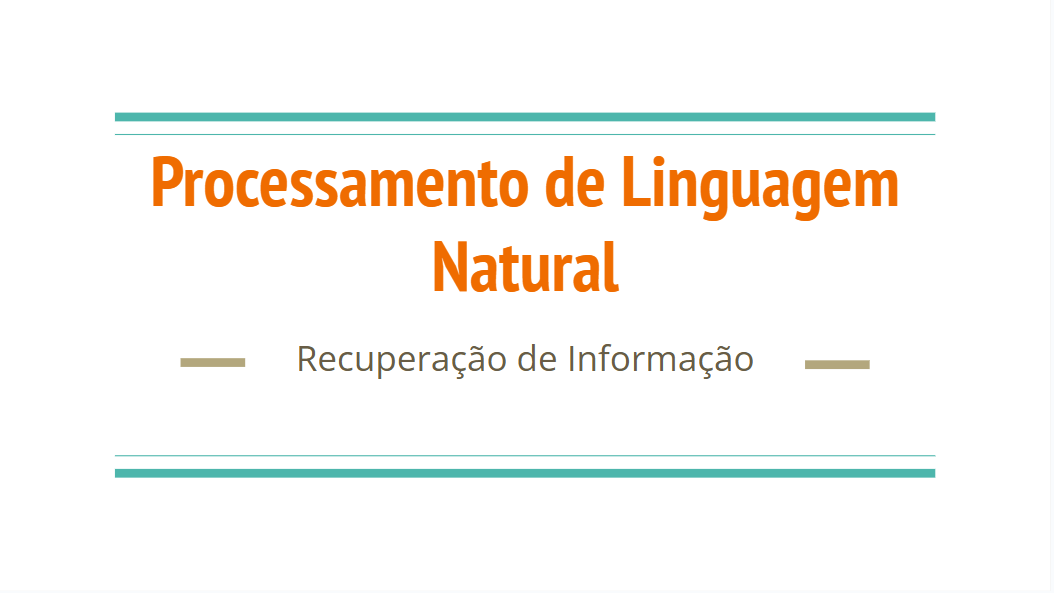

## Recuperação de Informação

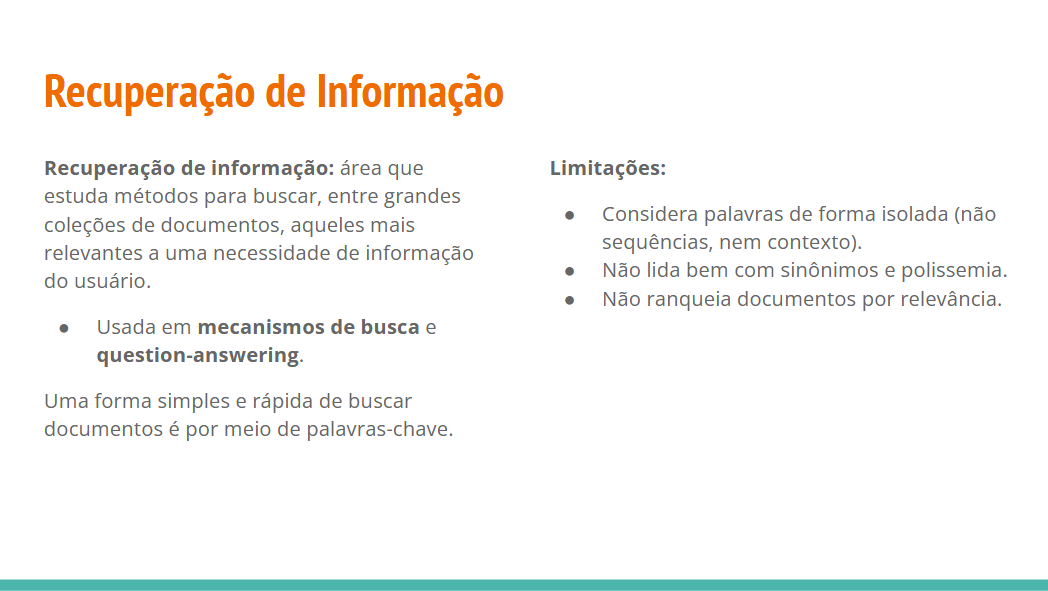

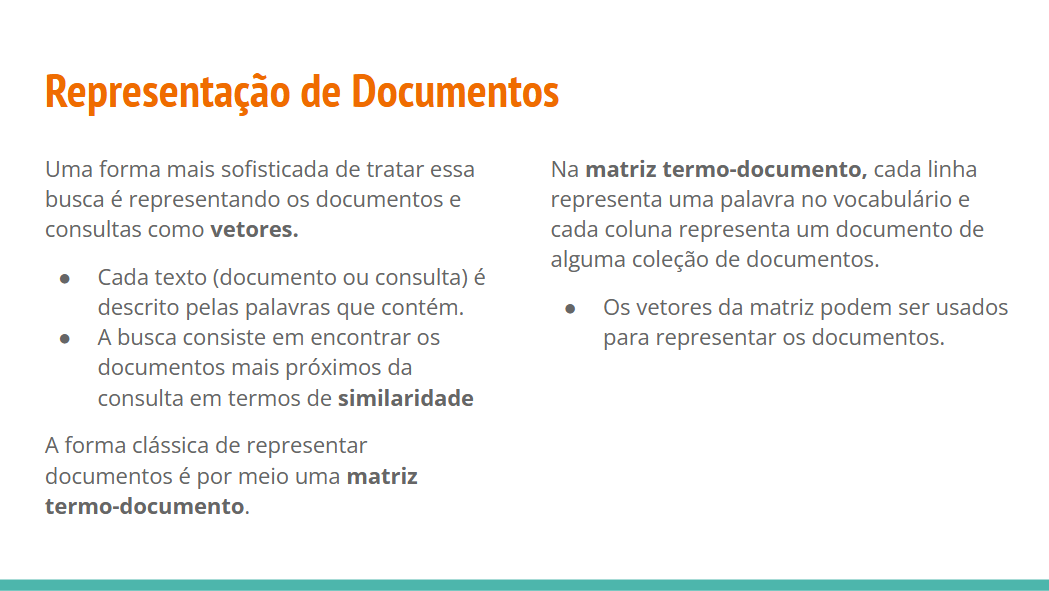

 Abaixo, temos um exemplo de **matriz termo-documento**. Ela mostra a ocorrência de quatro palavras em quatro peças de Shakespeare. Cada célula nesta matriz representa o número de vezes que uma palavra específica (definida pela linha) aparece em um documento específico (definido pela coluna). Por exemplo, a palavra "fool" aparece 58 vezes na peça *Twelfth Night* (Noite de Reis).

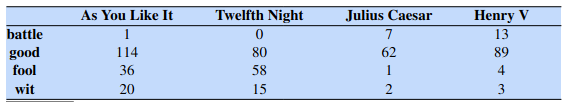

Matrizes termo-documento foram originalmente definidas como uma forma de encontrar documentos semelhantes na tarefa de recuperação de informação.

* Documentos semelhantes tendem a compartilhar muitas palavras.
* Portanto, seus vetores de coluna também tendem a ser semelhantes.

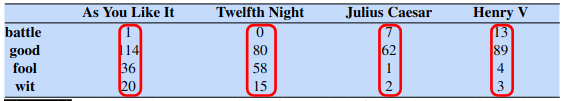

A figura abaixo mostra uma visualização dos vetores de documentos para quatro peças de Shakespeare em duas dimensões ("battle" e "fool").
* As comédias têm valores altos em "fool" e baixos em "battle".
* As tragédias possuem valores altos de "battle" e baixos de "fool".

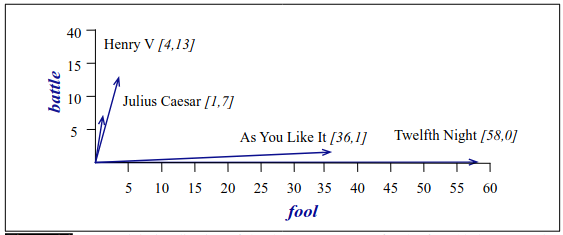

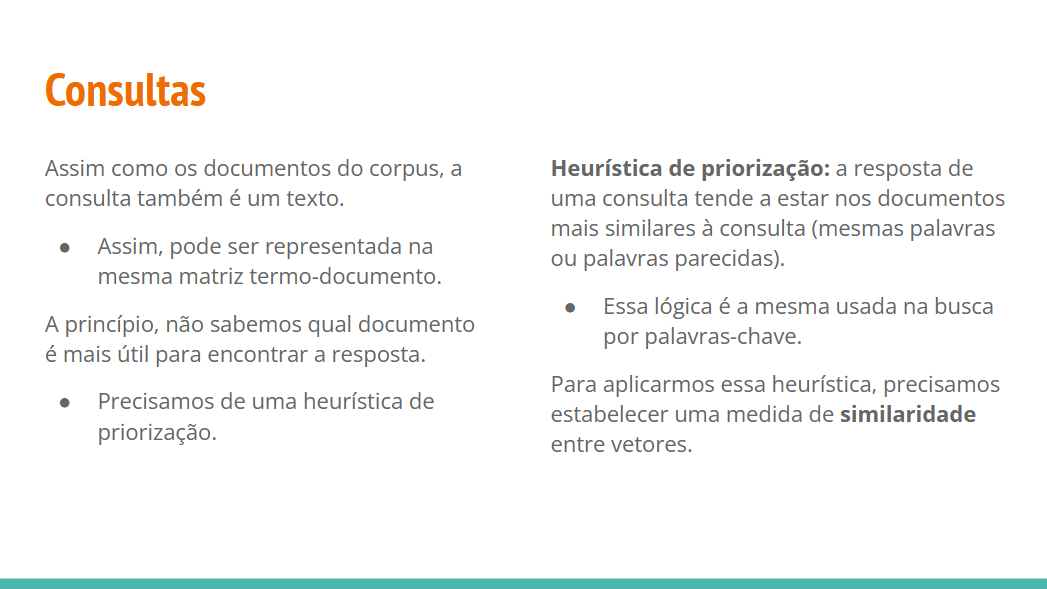

## Similaridade

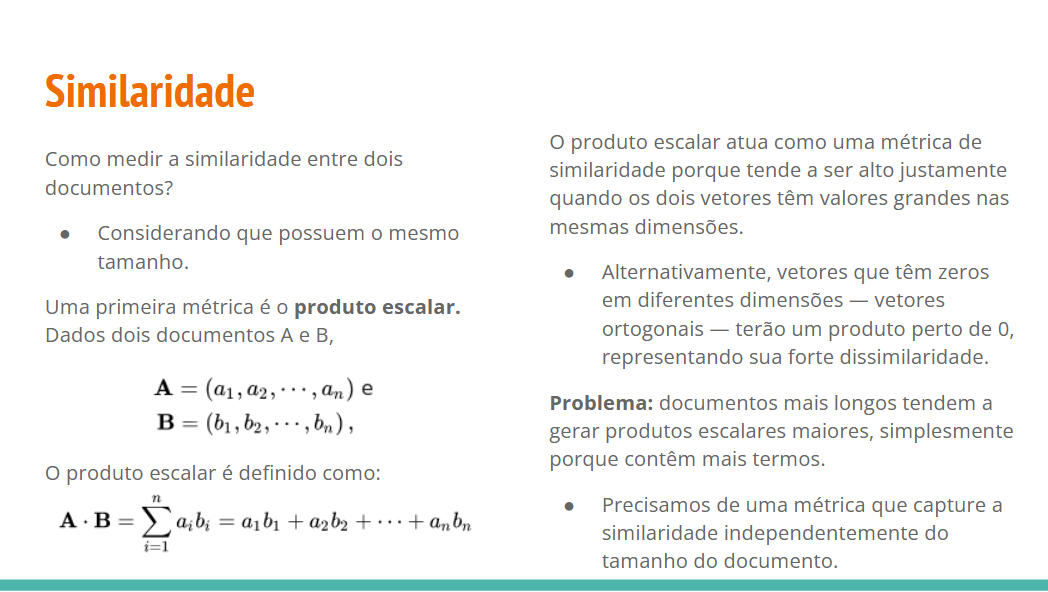

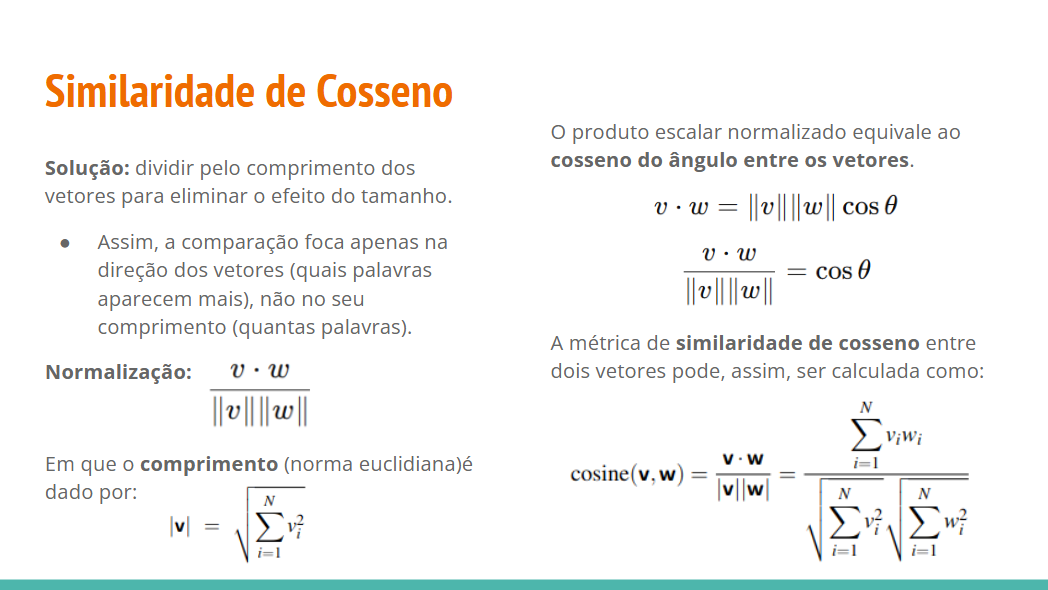

De maneira intuitiva, **dois vetores são similares** quando o ângulo entre eles é pequeno.

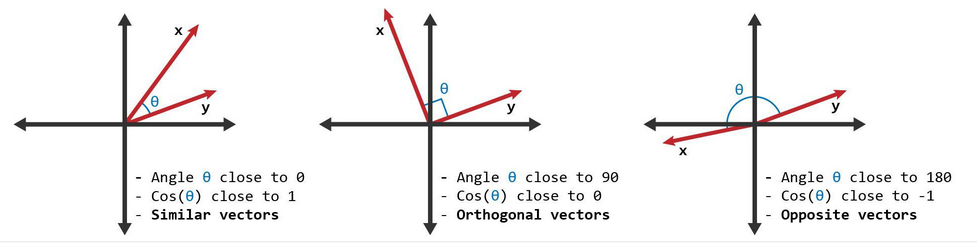

Vejamos como calcular a similaridade entre as peças de Shakespeare usando o exemplo anterior.

In [ ]:
# Peças de Shakespeare
docs = {
    "As You Like It": np.array([1, 14, 36, 20]),
    "Twelfth Night": np.array([0, 80, 58, 15]),
    "Julius Caesar": np.array([7, 62, 1, 2]),
    "Henry V": np.array([13, 89, 4, 3])
}

# Criar matriz com todos os documentos
doc_matrix = np.vstack(list(docs.values()))

# Calcular similaridade do cosseno
similarities = cosine_similarity(doc_matrix)

df_sim = pd.DataFrame(similarities, index=docs.keys(), columns=docs.keys())

df_sim

,As You Like It,Twelfth Night,Julius Caesar,Henry V
As You Like It,1.000000,0.806721,0.350094,0.373271
Twelfth Night,0.806721,1.000000,0.808979,0.821581
Julius Caesar,0.350094,0.808979,1.000000,0.999065
Henry V,0.373271,0.821581,0.999065,1.000000


## TF-IDF

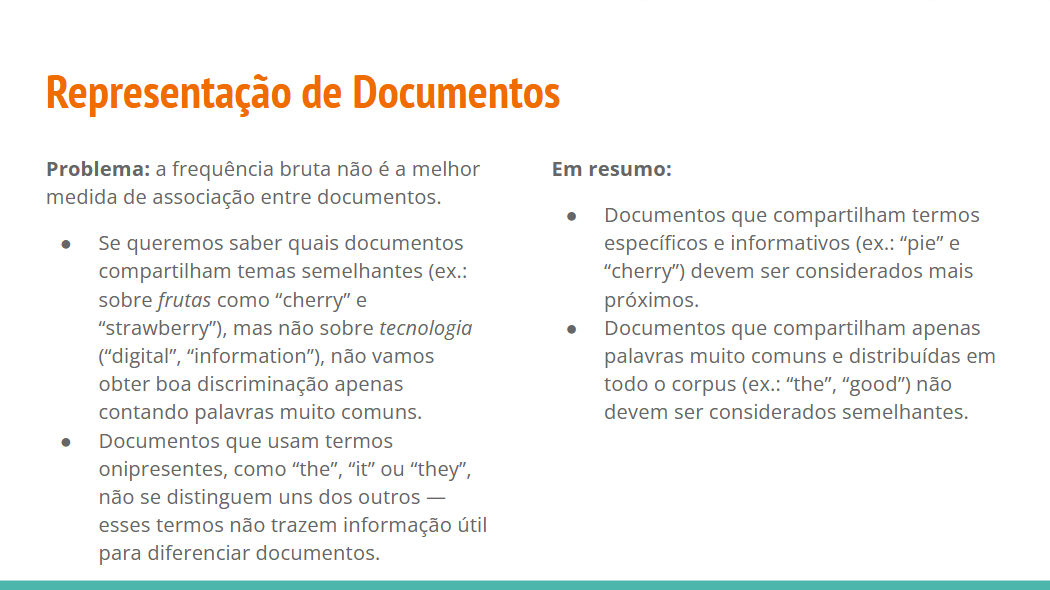

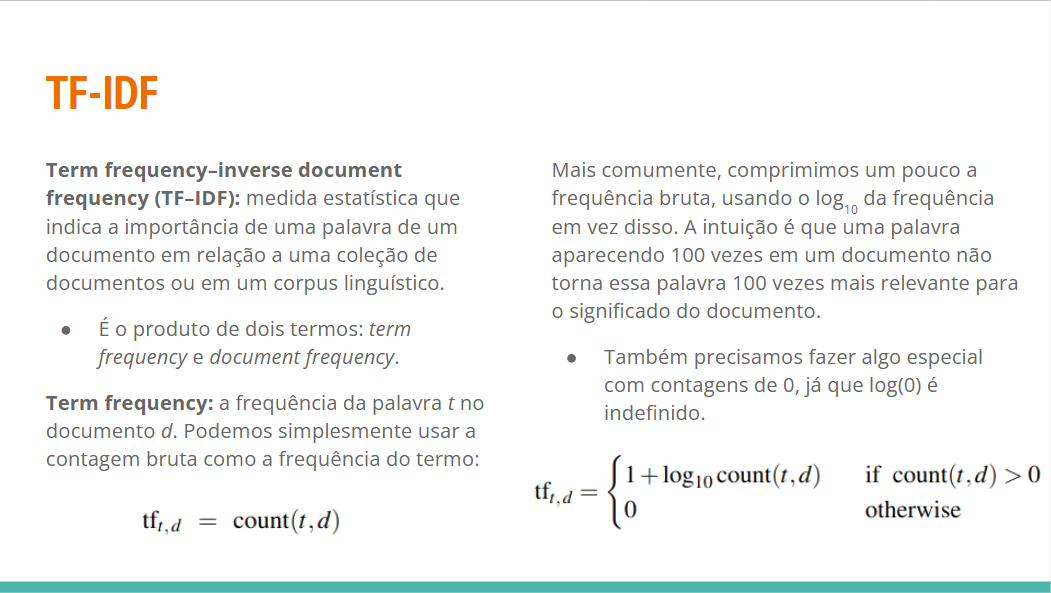

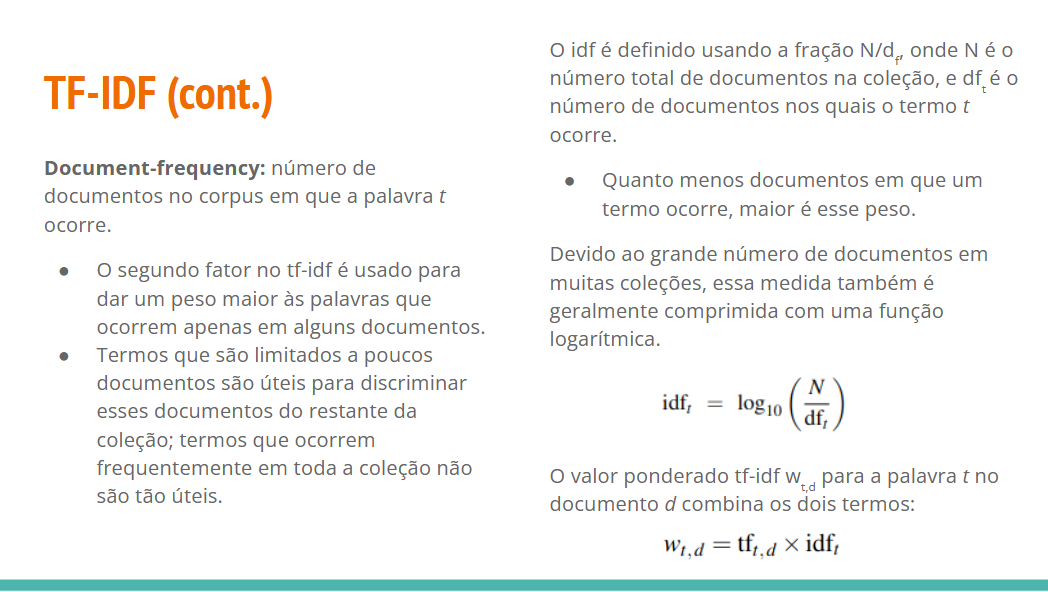

Vejamos um exemplo de representaçao **TF-IDF**. Nosso corpus consiste de quatro documentos.

In [ ]:
# Corpus
docs = [
    "o gato gosta de leite",
    "o cachorro gosta de osso",
    "o gato e o cachorro",
    "o leite é bom"
]

Podemos calcular a matriz termo-documento para esses documentos.

In [ ]:
# Matriz termo-documento original (contagens)
count_vectorizer = CountVectorizer()
X_counts = count_vectorizer.fit_transform(docs)
count_matrix = pd.DataFrame(X_counts.toarray(), columns=count_vectorizer.get_feature_names_out())

count_matrix

,bom,cachorro,de,gato,gosta,leite,osso
0,0,0,1,1,1,1,0
1,0,1,1,0,1,0,1
2,0,1,0,1,0,0,0
3,1,0,0,0,0,1,0


E agora, sua representação com a ponderação **TF-IDF**.

In [ ]:
# Matriz TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(docs)
tfidf_matrix = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

tfidf_matrix

,bom,cachorro,de,gato,gosta,leite,osso
0,0.000000,0.000000,0.500000,0.500000,0.500000,0.50000,0.000000
1,0.000000,0.465809,0.465809,0.000000,0.465809,0.00000,0.590819
2,0.000000,0.707107,0.000000,0.707107,0.000000,0.00000,0.000000
3,0.785288,0.000000,0.000000,0.000000,0.000000,0.61913,0.000000


As duas matrizes têm efeitos diferentes para o cálculo de similaridades.

In [ ]:
# Similaridade com contagens brutas
sim_counts = cosine_similarity(X_counts.toarray())

# Similaridade com TF-IDF
sim_tfidf = cosine_similarity(X_tfidf.toarray())

# DataFrames para visualização
sim_counts_df = pd.DataFrame(sim_counts, index=[f"D{i+1}" for i in range(len(docs))], columns=[f"D{i+1}" for i in range(len(docs))])
sim_tfidf_df = pd.DataFrame(sim_tfidf, index=[f"D{i+1}" for i in range(len(docs))], columns=[f"D{i+1}" for i in range(len(docs))])

print('Matriz original')
print(sim_counts_df, '\n')
print('Matriz com TF-IDF')
print(sim_tfidf_df)

Matriz original
          D1        D2        D3        D4
D1  1.000000  0.500000  0.353553  0.353553
D2  0.500000  1.000000  0.353553  0.000000
D3  0.353553  0.353553  1.000000  0.000000
D4  0.353553  0.000000  0.000000  1.000000 

Matriz com TF-IDF
          D1        D2        D3        D4
D1  1.000000  0.465809  0.353553  0.309565
D2  0.465809  1.000000  0.329376  0.000000
D3  0.353553  0.329376  1.000000  0.000000
D4  0.309565  0.000000  0.000000  1.000000


### Aplicação

Vamos colocar em prática essa representação vetorial dos documentos para uma tarefa de **recuperação de informação**. No caso, vamos encontrar os 10 documentos mais similares a um dado documento, utilizando a similaridade de cosseno.

Para começar, vamos baixar nosso corpus, que consiste de notícias de jornais.

In [ ]:
newsgroups = fetch_20newsgroups(subset='all')
documents = newsgroups.data

print('Número de documentos:', len(documents))

Número de documentos: 18846


Vamos escolher um documento qualquer e inspecionar seu conteúdo.

In [ ]:
doc = documents[77]

print(doc)

From: jagrant@emr1.emr.ca (John Grant)
Subject: Re: head-to-head win and os/2
Organization: Energy, Mines, and Resources, Ottawa
Lines: 32

In article <1993May15.030210.4755@ccsvax.sfasu.edu> z_shererrg@ccsvax.sfasu.edu writes:
>After hearing endless debate (READ: name-calling) over which os is better, dos
>and windows or OS/2 and finally having enought resourses to play with a couple
>of different operating systems, I have decided to put the two products to a
>head to head test, as so many fellow newsposters have suggested.  I have, 
>however, no desire whatsoever to use a version of os/2 which wont REALLY
>do what it says (i.e. run windows apps)  OS/2 2.0-2.1 will not run windows
>apps in 386 enhansed mode, something that most larger windows apps require, but
>OS/2 2.2, which is supposed to be in beta test, is supposed to.  I have heard
>that os/2 2.2 beta is available via ftp, and I was wondering if anyone knew
>where to obtain a copy.  I would appreciate any information, as I would

Criamos uma matriz termo-documento usando a ponderação Tf-idf

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(documents)

Escolhemos um documento aleatório

In [ ]:
np.random.seed(42)

random_idx = np.random.randint(len(documents))
random_doc = X[random_idx]

Obtemos a similaridade de cosseno entre o documento escolhido e todos os outros documentos

In [ ]:
cosine_similarities = cosine_similarity(random_doc, X).flatten()

Ordenamos os documentos por similaridade

In [ ]:
similar_docs_idx = cosine_similarities.argsort()[-11:-1][::-1]

# Explicação:
# 'cosine_similarities: array que contém os valores de similaridade de cosseno entre o documento de referência e todos os outros documentos.
# 'argsort(): retorna os índices que ordenariam o array em ordem crescente.
# [-11:-1]: seleciona os 10 maiores elementos, com exceção do último (que é o próprio documento)
# [::-1]: retorna o array em ordem decrescente, do mais similar ao menos similar

Por último, imprimimos os 10 documentos mais similares

In [ ]:
print(similar_docs_idx)
print("Documento escolhido:\n")
print(documents[random_idx])
print("\n\nDocumentos mais similares:\n")
for idx in similar_docs_idx:
    print(f"Similaridade: {cosine_similarities[idx]:.4f}")
    print(documents[idx])
    print("\n" + "-"*80 + "\n")

[14553  5311  8565 17111 12885 14931 15068 17115 12316  7970]
Documento escolhido:

From: mangoe@cs.umd.edu (Charley Wingate)
Subject: Re: A Little Too Satanic
Organization: U of Maryland, Dept. of Computer Science, Coll. Pk., MD 20742
Lines: 43

Jon Livesey writes:

>So why do I read in the papers that the Qumram texts had "different
>versions" of some OT texts.   Did I misunderstand?

Reading newspapers to learn about this kind of stuff is not the best idea in
the world.  Newspaper reporters are notoriously ignorant on the subject of
religion, and are prone to exaggeration in the interests of having a "real"
story (that is, a bigger headline).

Let's back up to 1935.  At this point, we have the Masoretic text, the
various targums (translations/commentaries in aramaic, etc.), and the
Septuagint, the ancient greek translation.  The Masoretic text is the
standard Jewish text and essentially does not vary.  In some places it has
obvious corruptions, all of which are copied faithfully fro

**Extra:** Organize todas essas etapas em uma única função. Esta função deve receber três argumentos:

1.   Corpus;
2.   Índice do documento a ser avaliado;
3.   Número de documentos a serem retornados.

In [ ]:
def find_similar_documents(corpus, doc_index, k):
    """
    Encontra os k documentos mais similares a um documento específico em um corpus.

    Parâmetros:
    corpus (list): Lista de documentos (strings).
    doc_index (int): Índice do documento a ser usado como referência.
    k (int): Número de documentos mais similares a serem retornados.

    Retorna:
    dict: Um dicionário contendo o documento de referência e os k documentos mais similares com suas similaridades.
    """
    # Criar a matriz termo-documento usando TF-IDF
    vectorizer = TfidfVectorizer(stop_words='english')
    X = vectorizer.fit_transform(corpus)

    # Obter o documento de referência
    reference_doc = X[doc_index]

    # Calcular a similaridade de cosseno entre o documento de referência e todos os outros documentos
    cosine_similarities = cosine_similarity(reference_doc, X).flatten()

    # Rankear os k documentos mais similares (excluindo o próprio documento de referência)
    similar_docs_idx = cosine_similarities.argsort()[-(k+1):-1][::-1]

    # Preparar o resultado
    result = {
        "documento_referencia": corpus[doc_index],
        "documentos_similares": []
    }

    for idx in similar_docs_idx:
        result["documentos_similares"].append({
            "indice": idx,
            "similaridade": cosine_similarities[idx],
            "documento": corpus[idx]
        })

    return result

In [ ]:
# Exemplo de uso
newsgroups = fetch_20newsgroups(subset='all')
documents = newsgroups.data

# Escolher um índice de documento aleatório
doc_index = np.random.randint(len(documents))
k = 10

# Encontrar documentos similares
resultado = find_similar_documents(documents, doc_index, k)

In [ ]:
# Imprimir os resultados
print("Documento de Referência:\n")
print(resultado["documento_referencia"])
print("\n\nDocumentos Mais Similares:\n")

for doc in resultado["documentos_similares"]:
    print(f"Índice: {doc['indice']}")
    print(f"Similaridade: {doc['similaridade']:.4f}")
    print(doc["documento"])
    print("\n" + "-"*80 + "\n")

Documento de Referência:

From: kerney@ecn.purdue.edu (John Kerney)
Subject: Re: FLYERS notes 4/17
Keywords: FLYERS/Whalers summary
Organization: Purdue University Engineering Computer Network
Lines: 17



Could someone post the Flyers record with and without Eric Lindros in
the lineup


I have a guy that is trying to compare the Quebec/Flyers trade to the 

Dallas/Minnesota trade in the NFL(Hershel Walker)

I just need the stat to back up my point that Eric will be one of the next

great players

thanks

john



Documentos Mais Similares:

Índice: 10633
Similaridade: 0.3736
From: seth@cbnewsh.cb.att.com (peter.r.clark..jr)
Subject: FLYERS notes 4/5
Organization: AT&T
Keywords: FLYERS/Leafs summary (take that, Leafs woofers!)
Lines: 225



The FLYERS team that can beat any team on any night showed up at the Spectrum
Sunday night, and dominated the Maple Leafs thoroughly en route to a 4-0
shutout. Tommy Soderstrom will get credit for the shutout, but he barely broke
a sweat until the th

## Question Answering

Outro uso importante para recuperação de informação é no contexto de question answering. Uma forma de responder uma pergunta é encontrar textos que possam conter a resposta.

A forma de encontrar esses textos é comparar o vetor da questão com o vetor dos textos, retornando os que possuem maior similaridade com a pergunta. Essa estratégia está na base das modernas arquiteturas RAG.

**Problema:** Escolha um dataset de question answering, como o Squad e o MSMarco, e retorne os textos mais similares a uma determinada pergunta. Esses datasets podem ser baixados pelo HuggingFace:

https://huggingface.co/datasets/rajpurkar/squad

https://huggingface.co/datasets/microsoft/ms_marco


In [ ]:
from datasets import load_dataset

# Carrega o dataset squad
df = load_dataset("rajpurkar/squad")

# Seleciona as questões
questions = df['train']['question']

# Seleciona as passagens
passages = df['train']['context']

# # Carrega o dataset msmarco
# df = load_dataset("microsoft/ms_marco", "v2.1")

# # Seleciona as questões
# questions = df['train']['query']

# # Seleciona as passagens
# passages = [passage['passage_text'][0] for passage in df['train']['passages']]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

In [ ]:
def find_similar_passages(questions, passages, question_index, k):
    vectorizer = TfidfVectorizer(stop_words='english')
    X_passages = vectorizer.fit_transform(passages)

    # Converter para int aqui garante compatibilidade
    reference_question = questions[int(question_index)]
    reference_question_vec = vectorizer.transform([reference_question])

    cosine_similarities = cosine_similarity(reference_question_vec, X_passages).flatten()
    similar_docs_idx = cosine_similarities.argsort()[-k:][::-1]

    result = {"pergunta_referencia": reference_question, "textos_similares": []}
    for idx in similar_docs_idx:
        result["textos_similares"].append({
            "indice": int(idx),
            "similaridade": float(cosine_similarities[idx]),
            "texto": passages[int(idx)],
        })
    return result

In [ ]:
# Exemplo de uso
question_index = np.random.randint(len(questions))
k = 3

# Encontrar textos similares
resultado = find_similar_passages(questions, passages, question_index, k)

In [ ]:
# Imprimir os resultados
print(f"Pergunta de Referência: {resultado['pergunta_referencia']}\n")

print(f'Passagem correta. Índice: {question_index}')
print(f'Texto com a resposta: {passages[question_index]}\n')
print('--------------')

for doc in resultado["textos_similares"]:
    print(f"Índice: {doc['indice']}")
    print(f"Similaridade: {doc['similaridade']:.4f}")
    print(doc["texto"])
    print("\n" + "-"*80 + "\n")

Pergunta de Referência: What game played in both Britain and America has become increasingly popular in pubs?

Passagem correta. Índice: 12515
Texto com a resposta: Traditional games are played in pubs, ranging from the well-known darts, skittles, dominoes, cards and bar billiards, to the more obscure Aunt Sally, Nine Men's Morris and ringing the bull. In the UK betting is legally limited to certain games such as cribbage or dominoes, played for small stakes. In recent decades the game of pool (both the British and American versions) has increased in popularity as well as other table based games such as snooker or Table Football becoming common.

--------------
Índice: 12477
Similaridade: 0.4150
Pubs that cater for a niche clientele, such as sports fans or people of certain nationalities are known as theme pubs. Examples of theme pubs include sports bars, rock pubs, biker pubs, Goth pubs, strip pubs, gay bars, karaoke bars and Irish pubs.

----------------------------------------------